In [1]:
# Cell 1: Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Cell 2: Load Supplementary Data
# Load supplementary data to understand the context
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\raw\\supplementary_data.csv')

# Display basic info
print("Supplementary Data Shape:", supp_data.shape)
print("\nFirst few rows:")
supp_data.head()

Supplementary Data Shape: (18009, 41)

First few rows:


,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,team_coverage_type,penalty_yards,pre_penalty_yards_gained,yards_gained,expected_points,expected_points_added,pre_snap_home_team_win_probability,pre_snap_visitor_team_win_probability,home_team_win_probability_added,visitor_team_win_probility_added
0,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,3461,(10:46) (Shotgun) J.Goff pass deep left to J.R...,4,...,COVER_2_ZONE,NaN,18,18,-0.664416,2.945847,0.834296,0.165704,-0.081149,0.081149
1,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,461,(7:30) J.Goff pass short right to J.Reynolds t...,1,...,COVER_6_ZONE,NaN,21,21,1.926131,1.345633,0.544618,0.455382,-0.029415,0.029415
2,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1940,(:09) (Shotgun) J.Goff pass incomplete deep ri...,2,...,COVER_2_ZONE,NaN,0,0,0.281891,-0.081964,0.771994,0.228006,0.000791,-0.000791
3,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1711,"(:45) (No Huddle, Shotgun) P.Mahomes pass deep...",2,...,COVER_2_ZONE,NaN,26,26,3.452352,2.342947,0.663187,0.336813,0.041843,-0.041843
4,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1588,(1:54) (Shotgun) P.Mahomes pass incomplete dee...,2,...,COVER_4_ZONE,NaN,0,0,1.921525,-0.324035,0.615035,0.384965,0.000061,-0.000061


In [4]:
# Cell 3: Define Red Zone Helper Functions
def parse_game_clock(clock_str):
    """Convert game clock string to seconds"""
    try:
        parts = clock_str.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

def is_in_redzone(yardline_number, yardline_side, possession_team):
    """
    Determine if play is in red zone (within 20 yards of opponent's end zone)
    Red zone = yardline_number <= 20 when yardline_side is opponent's side
    """
    # If the yardline_side matches possession team, they're on their own side (not red zone)
    # If yardline_side is opponent's side and yardline_number <= 20, it's red zone
    if yardline_side != possession_team and yardline_number <= 20:
        return True
    return False

# Apply game clock parsing
supp_data['game_clock_seconds'] = supp_data['game_clock'].apply(parse_game_clock)

# Identify red zone situations
supp_data['is_redzone'] = supp_data.apply(
    lambda row: is_in_redzone(row['yardline_number'], row['yardline_side'], row['possession_team']),
    axis=1
)

# Calculate distance to end zone for all plays
def calculate_distance_to_endzone(row):
    """Calculate actual distance to opponent's end zone"""
    if row['yardline_side'] == row['possession_team']:
        # On own side of field
        return 50 + (50 - row['yardline_number'])
    else:
        # On opponent's side
        return row['yardline_number']

supp_data['distance_to_endzone'] = supp_data.apply(calculate_distance_to_endzone, axis=1)

print(f"Total plays: {len(supp_data)}")
print(f"Red zone plays: {supp_data['is_redzone'].sum()}")
print(f"Red zone percentage: {supp_data['is_redzone'].sum() / len(supp_data) * 100:.2f}%")

Total plays: 18009
Red zone plays: 2146
Red zone percentage: 11.92%


In [6]:
# Cell 4: Load and Merge Tracking Data
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')


# Load all weeks using pathlib for cross-platform compatibility
input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))
output_files = sorted(BASE_PATH.glob('output_2023_w*.csv'))

print(f"Found {len(input_files)} input files")
print(f"Found {len(output_files)} output files")

# Load and concatenate all input data
input_dfs = []
for file in sorted(input_files):
    df = pd.read_csv(file)
    input_dfs.append(df)

input_data = pd.concat(input_dfs, ignore_index=True)
print(f"\nTotal input tracking records: {len(input_data)}")

# Merge with supplementary data to get red zone context
merged_data = input_data.merge(
    supp_data[['game_id', 'play_id', 'is_redzone', 'distance_to_endzone', 'quarter', 
               'down', 'yards_to_go', 'pass_result', 'offense_formation', 
               'team_coverage_type', 'expected_points_added', 'yards_gained']],
    on=['game_id', 'play_id'],
    how='left'
)

print(f"Merged data shape: {merged_data.shape}")
print(f"Red zone tracking records: {merged_data['is_redzone'].sum()}")

Found 18 input files
Found 18 output files

Total input tracking records: 4880579
Merged data shape: (4880579, 33)
Red zone tracking records: 546961


In [7]:
# Cell 5: Red Zone Play Analysis
# Filter for red zone plays only
redzone_plays = supp_data[supp_data['is_redzone'] == True].copy()

print("="*60)
print("RED ZONE ANALYSIS")
print("="*60)

# Pass result distribution in red zone
print("\n1. Pass Result Distribution in Red Zone:")
pass_result_dist = redzone_plays['pass_result'].value_counts()
print(pass_result_dist)
print(f"\nCompletion Rate: {pass_result_dist.get('C', 0) / len(redzone_plays) * 100:.2f}%")
print(f"Interception Rate: {pass_result_dist.get('IN', 0) / len(redzone_plays) * 100:.2f}%")

# Down distribution
print("\n2. Down Distribution in Red Zone:")
print(redzone_plays['down'].value_counts().sort_index())

# Formation analysis
print("\n3. Top Offensive Formations in Red Zone:")
print(redzone_plays['offense_formation'].value_counts().head(10))

# Coverage analysis
print("\n4. Top Defensive Coverages in Red Zone:")
print(redzone_plays['team_coverage_type'].value_counts().head(10))

RED ZONE ANALYSIS

1. Pass Result Distribution in Red Zone:
pass_result
C     1338
I      757
IN      51
Name: count, dtype: int64

Completion Rate: 62.35%
Interception Rate: 2.38%

2. Down Distribution in Red Zone:
down
1    610
2    732
3    688
4    116
Name: count, dtype: int64

3. Top Offensive Formations in Red Zone:
offense_formation
SHOTGUN       1495
EMPTY          289
SINGLEBACK     225
PISTOL          63
I_FORM          43
JUMBO           30
WILDCAT          1
Name: count, dtype: int64

4. Top Defensive Coverages in Red Zone:
team_coverage_type
COVER_1_MAN     622
COVER_4_ZONE    505
COVER_0_MAN     454
COVER_3_ZONE    389
COVER_2_ZONE    109
COVER_6_ZONE     50
COVER_2_MAN      16
PREVENT           1
Name: count, dtype: int64


In [8]:
# Cell 6: Red Zone Success Metrics
# Define success in red zone (touchdown or significant yards gained)
redzone_plays['is_touchdown'] = redzone_plays['yards_gained'] >= redzone_plays['distance_to_endzone']
redzone_plays['is_successful'] = (
    (redzone_plays['pass_result'] == 'C') & 
    ((redzone_plays['yards_gained'] >= redzone_plays['yards_to_go']) | 
     (redzone_plays['is_touchdown']))
)

print("Red Zone Success Metrics:")
print(f"Touchdown Rate: {redzone_plays['is_touchdown'].sum() / len(redzone_plays) * 100:.2f}%")
print(f"Success Rate: {redzone_plays['is_successful'].sum() / len(redzone_plays) * 100:.2f}%")
print(f"Average EPA: {redzone_plays['expected_points_added'].mean():.3f}")
print(f"Average Yards Gained: {redzone_plays['yards_gained'].mean():.2f}")

# Success by down
print("\nSuccess Rate by Down:")
for down in sorted(redzone_plays['down'].unique()):
    down_plays = redzone_plays[redzone_plays['down'] == down]
    success_rate = down_plays['is_successful'].sum() / len(down_plays) * 100
    print(f"  Down {down}: {success_rate:.2f}% ({len(down_plays)} plays)")

Red Zone Success Metrics:
Touchdown Rate: 29.59%
Success Rate: 41.61%
Average EPA: 0.257
Average Yards Gained: 4.53

Success Rate by Down:
  Down 1: 35.41% (610 plays)
  Down 2: 40.85% (732 plays)
  Down 3: 46.37% (688 plays)
  Down 4: 50.86% (116 plays)


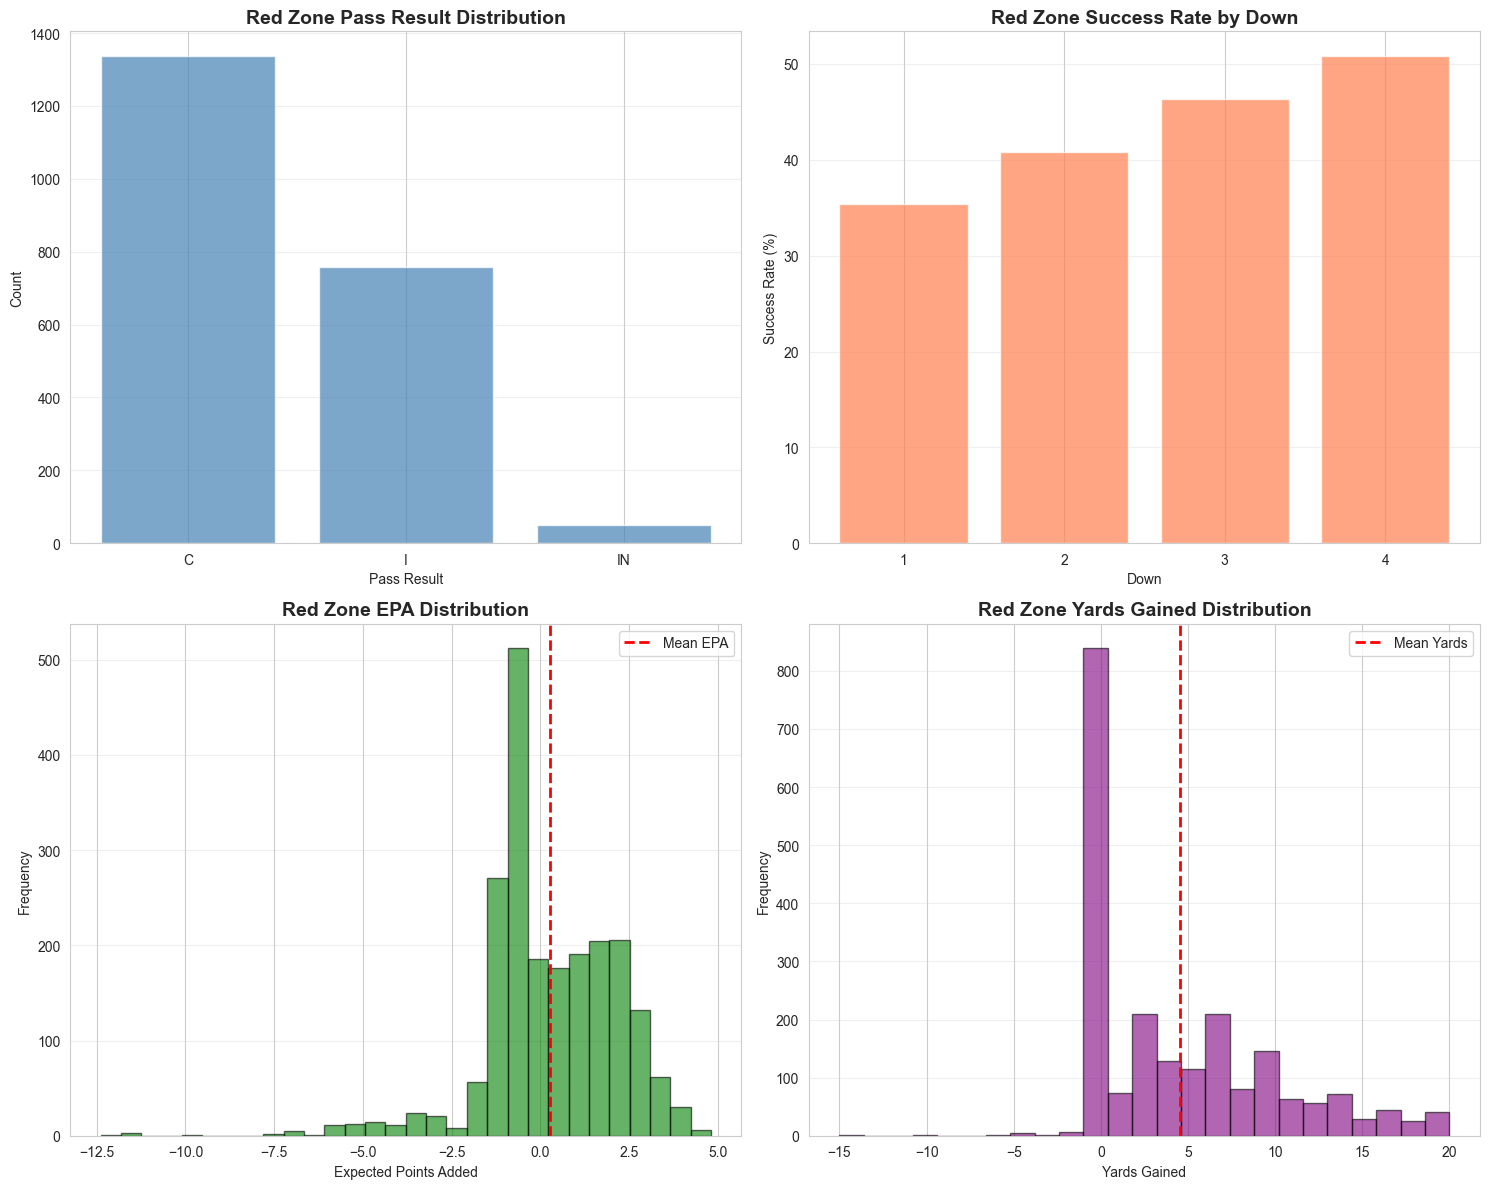

In [9]:
# Cell 7: Visualization - Red Zone Pass Results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Pass Result Distribution
pass_results = redzone_plays['pass_result'].value_counts()
axes[0, 0].bar(pass_results.index, pass_results.values, color='steelblue', alpha=0.7)
axes[0, 0].set_title('Red Zone Pass Result Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Pass Result')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Success Rate by Down
down_success = redzone_plays.groupby('down')['is_successful'].agg(['sum', 'count'])
down_success['rate'] = (down_success['sum'] / down_success['count']) * 100
axes[0, 1].bar(down_success.index, down_success['rate'], color='coral', alpha=0.7)
axes[0, 1].set_title('Red Zone Success Rate by Down', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Down')
axes[0, 1].set_ylabel('Success Rate (%)')
axes[0, 1].set_xticks([1, 2, 3, 4])
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: EPA Distribution
axes[1, 0].hist(redzone_plays['expected_points_added'].dropna(), bins=30, 
                color='green', alpha=0.6, edgecolor='black')
axes[1, 0].axvline(redzone_plays['expected_points_added'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean EPA')
axes[1, 0].set_title('Red Zone EPA Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Expected Points Added')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Yards Gained Distribution
axes[1, 1].hist(redzone_plays['yards_gained'].dropna(), bins=25, 
                color='purple', alpha=0.6, edgecolor='black')
axes[1, 1].axvline(redzone_plays['yards_gained'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean Yards')
axes[1, 1].set_title('Red Zone Yards Gained Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Yards Gained')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

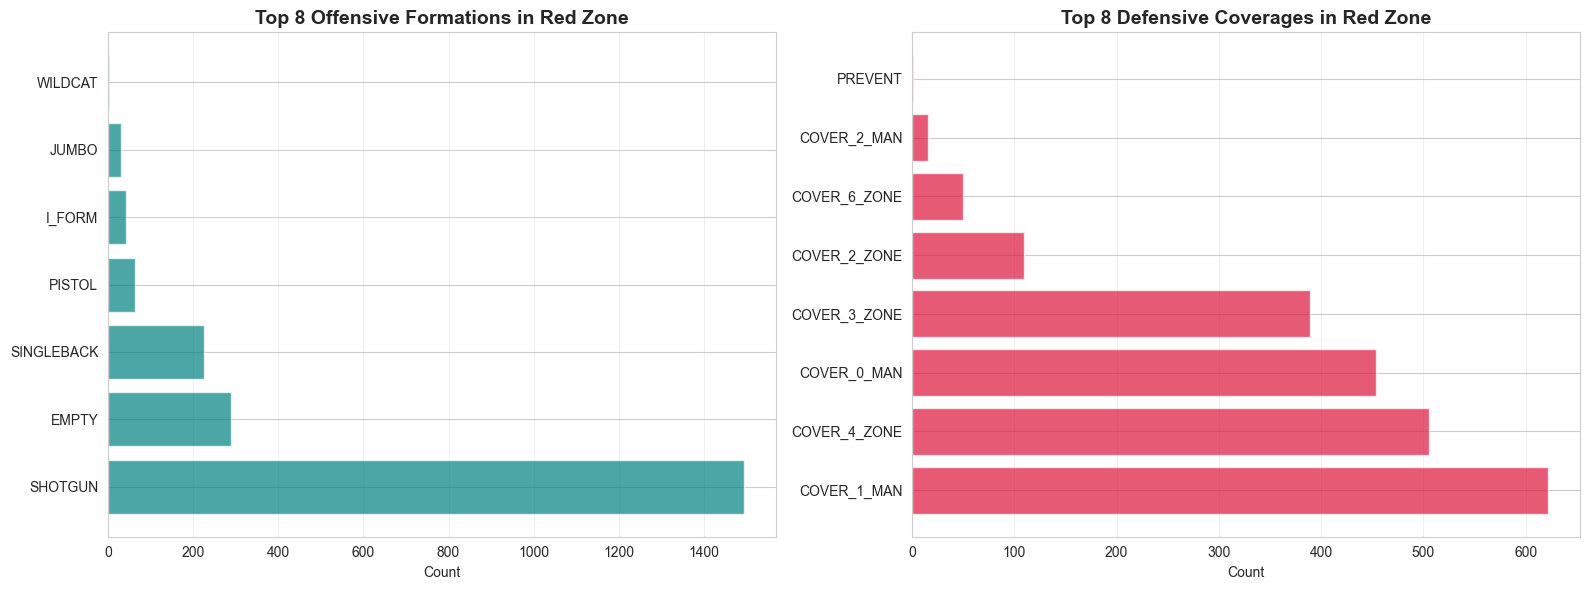

In [10]:
# Cell 8: Formation and Coverage Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top formations in red zone
top_formations = redzone_plays['offense_formation'].value_counts().head(8)
axes[0].barh(range(len(top_formations)), top_formations.values, color='teal', alpha=0.7)
axes[0].set_yticks(range(len(top_formations)))
axes[0].set_yticklabels(top_formations.index)
axes[0].set_title('Top 8 Offensive Formations in Red Zone', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# Top coverages in red zone
top_coverages = redzone_plays['team_coverage_type'].value_counts().head(8)
axes[1].barh(range(len(top_coverages)), top_coverages.values, color='crimson', alpha=0.7)
axes[1].set_yticks(range(len(top_coverages)))
axes[1].set_yticklabels(top_coverages.index)
axes[1].set_title('Top 8 Defensive Coverages in Red Zone', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Cell 9: Player Movement Analysis in Red Zone
# Analyze player tracking data in red zone
redzone_tracking = merged_data[merged_data['is_redzone'] == True].copy()

print("Red Zone Player Tracking Analysis:")
print(f"Total tracking frames in red zone: {len(redzone_tracking)}")

# Analyze by player role
print("\nPlayer Role Distribution in Red Zone:")
role_dist = redzone_tracking['player_role'].value_counts()
print(role_dist)

# Speed and acceleration analysis by role
print("\nAverage Speed by Player Role:")
speed_by_role = redzone_tracking.groupby('player_role')['s'].mean().sort_values(ascending=False)
print(speed_by_role)

print("\nAverage Acceleration by Player Role:")
accel_by_role = redzone_tracking.groupby('player_role')['a'].mean().sort_values(ascending=False)
print(accel_by_role)

# Analyze targeted receivers
targeted_receivers = redzone_tracking[redzone_tracking['player_role'] == 'Targeted Receiver']
print(f"\nTargeted Receiver Frames: {len(targeted_receivers)}")
print(f"Average Speed: {targeted_receivers['s'].mean():.2f} yards/sec")
print(f"Average Acceleration: {targeted_receivers['a'].mean():.2f} yards/sec²")

Red Zone Player Tracking Analysis:
Total tracking frames in red zone: 546961

Player Role Distribution in Red Zone:
player_role
Defensive Coverage    296062
Other Route Runner    161291
Passer                 44804
Targeted Receiver      44804
Name: count, dtype: int64

Average Speed by Player Role:
player_role
Targeted Receiver     3.832701
Other Route Runner    3.766619
Defensive Coverage    2.219443
Passer                1.883535
Name: s, dtype: float64

Average Acceleration by Player Role:
player_role
Targeted Receiver     2.700518
Other Route Runner    2.616563
Passer                1.881053
Defensive Coverage    1.792252
Name: a, dtype: float64

Targeted Receiver Frames: 44804
Average Speed: 3.83 yards/sec
Average Acceleration: 2.70 yards/sec²


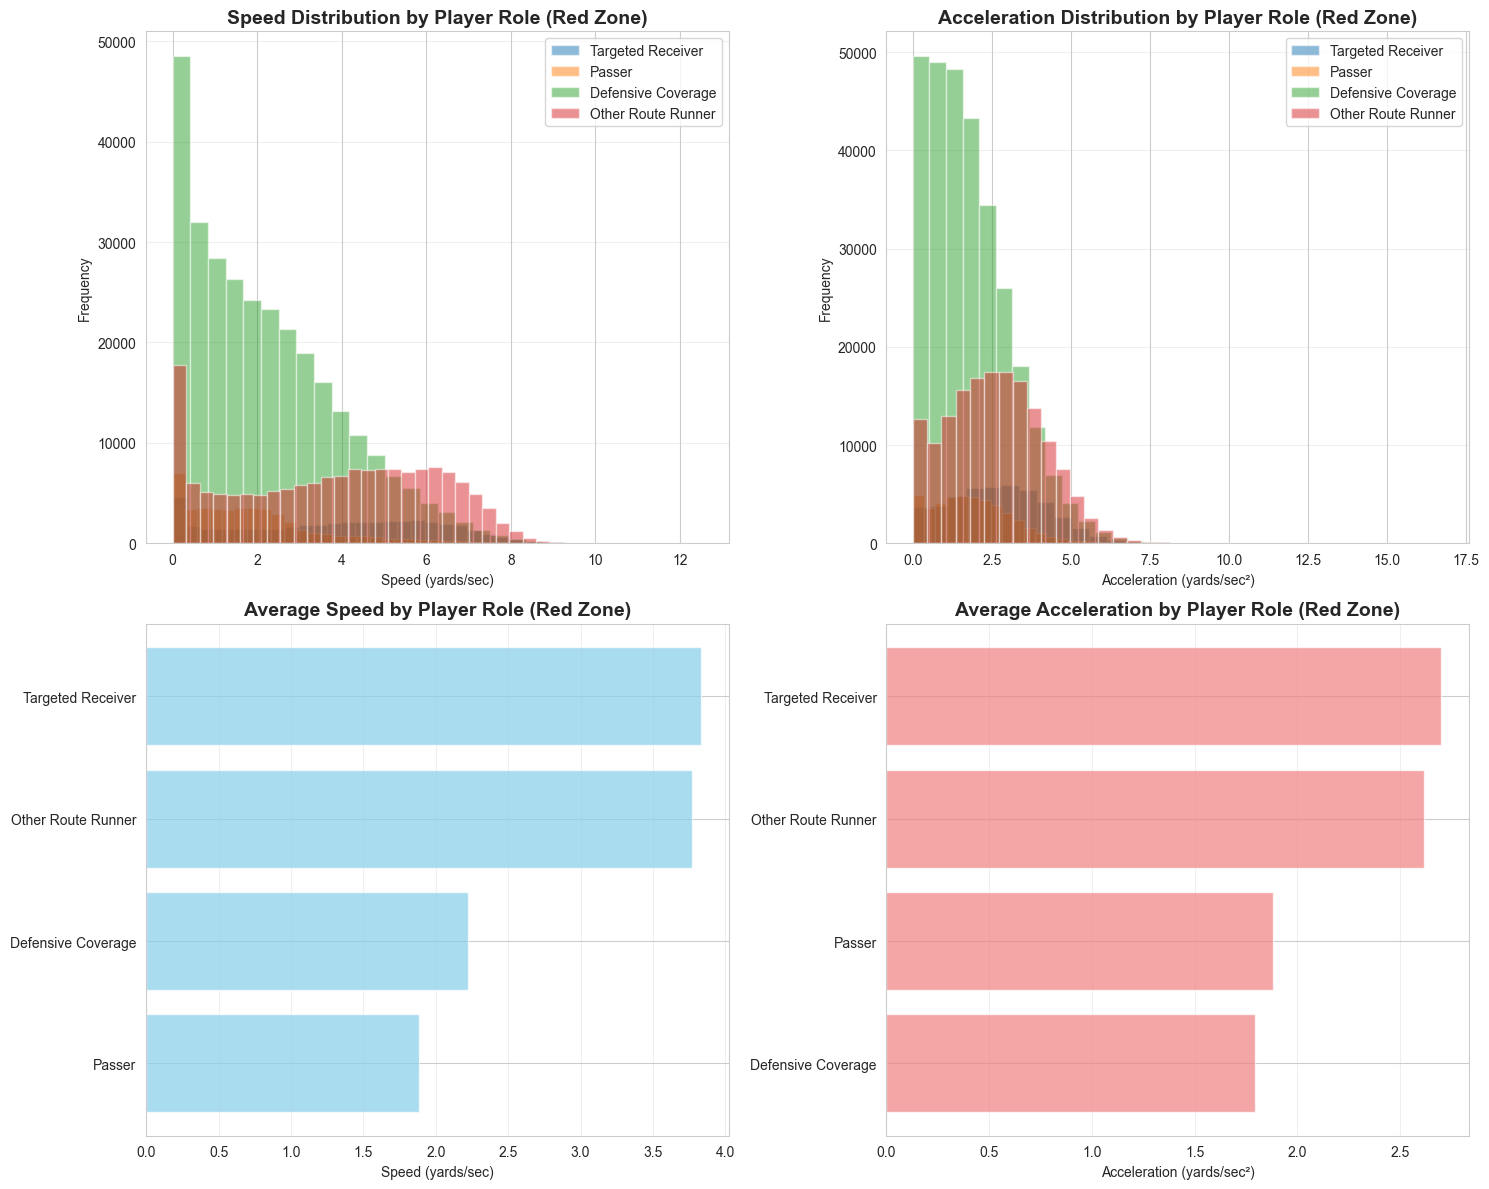

In [12]:
# Cell 10: Visualization - Player Movement in Red Zone
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Speed distribution by player role
roles = ['Targeted Receiver', 'Passer', 'Defensive Coverage', 'Other Route Runner']
for role in roles:
    role_data = redzone_tracking[redzone_tracking['player_role'] == role]['s'].dropna()
    if len(role_data) > 0:
        axes[0, 0].hist(role_data, bins=30, alpha=0.5, label=role)
axes[0, 0].set_title('Speed Distribution by Player Role (Red Zone)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Speed (yards/sec)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Acceleration distribution by player role
for role in roles:
    role_data = redzone_tracking[redzone_tracking['player_role'] == role]['a'].dropna()
    if len(role_data) > 0:
        axes[0, 1].hist(role_data, bins=30, alpha=0.5, label=role)
axes[0, 1].set_title('Acceleration Distribution by Player Role (Red Zone)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Acceleration (yards/sec²)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Average speed by role
avg_speed = redzone_tracking.groupby('player_role')['s'].mean().sort_values()
axes[1, 0].barh(range(len(avg_speed)), avg_speed.values, color='skyblue', alpha=0.7)
axes[1, 0].set_yticks(range(len(avg_speed)))
axes[1, 0].set_yticklabels(avg_speed.index)
axes[1, 0].set_title('Average Speed by Player Role (Red Zone)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Speed (yards/sec)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Average acceleration by role
avg_accel = redzone_tracking.groupby('player_role')['a'].mean().sort_values()
axes[1, 1].barh(range(len(avg_accel)), avg_accel.values, color='lightcoral', alpha=0.7)
axes[1, 1].set_yticks(range(len(avg_accel)))
axes[1, 1].set_yticklabels(avg_accel.index)
axes[1, 1].set_title('Average Acceleration by Player Role (Red Zone)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Acceleration (yards/sec²)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Cell 11: Distance to Ball Landing Spot Analysis
# Analyze how close players are to where the ball lands
redzone_tracking['distance_to_ball_land'] = np.sqrt(
    (redzone_tracking['x'] - redzone_tracking['ball_land_x'])**2 + 
    (redzone_tracking['y'] - redzone_tracking['ball_land_y'])**2
)

print("Distance to Ball Landing Spot Analysis (Red Zone):")
print("\nBy Player Role:")
dist_by_role = redzone_tracking.groupby('player_role')['distance_to_ball_land'].agg(['mean', 'median', 'std'])
print(dist_by_role)

# Analyze for targeted receivers specifically
targeted = redzone_tracking[redzone_tracking['player_role'] == 'Targeted Receiver']
print(f"\nTargeted Receivers:")
print(f"  Average distance to ball: {targeted['distance_to_ball_land'].mean():.2f} yards")
print(f"  Median distance to ball: {targeted['distance_to_ball_land'].median():.2f} yards")

# Defensive coverage
defense = redzone_tracking[redzone_tracking['player_role'] == 'Defensive Coverage']
print(f"\nDefensive Coverage:")
print(f"  Average distance to ball: {defense['distance_to_ball_land'].mean():.2f} yards")
print(f"  Median distance to ball: {defense['distance_to_ball_land'].median():.2f} yards")

Distance to Ball Landing Spot Analysis (Red Zone):

By Player Role:
                         mean     median        std
player_role                                        
Defensive Coverage  17.932863  16.533516   9.585606
Other Route Runner  20.673554  19.679239  10.503457
Passer              20.820525  19.603934   8.153489
Targeted Receiver   12.416484  11.424382   6.830004

Targeted Receivers:
  Average distance to ball: 12.42 yards
  Median distance to ball: 11.42 yards

Defensive Coverage:
  Average distance to ball: 17.93 yards
  Median distance to ball: 16.53 yards


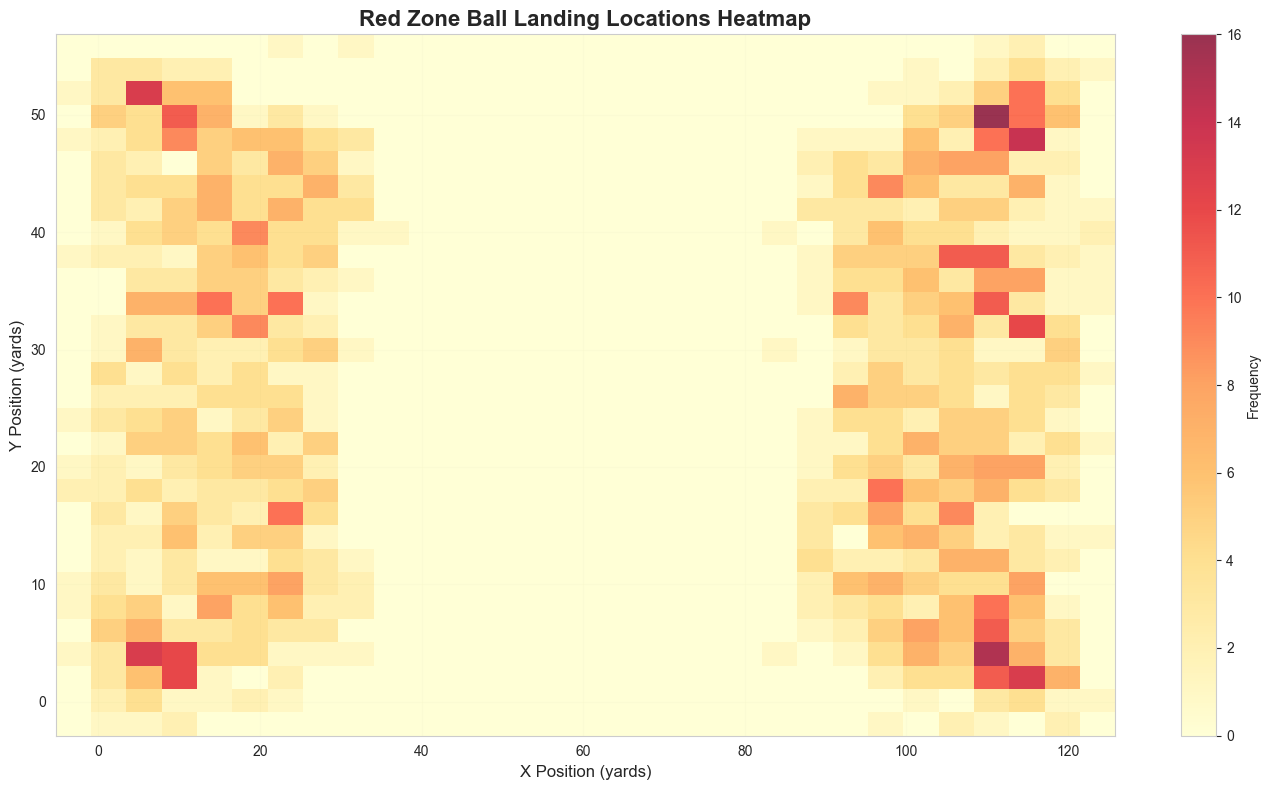

In [14]:
# Cell 12: Red Zone Heatmap - Ball Landing Locations
# Create heatmap of where balls land in red zone
fig, ax = plt.subplots(figsize=(14, 8))

# Get unique ball landing positions per play
ball_lands = redzone_tracking.groupby(['game_id', 'play_id']).first()[['ball_land_x', 'ball_land_y']].dropna()

# Create 2D histogram
h = ax.hist2d(ball_lands['ball_land_x'], ball_lands['ball_land_y'], 
              bins=30, cmap='YlOrRd', alpha=0.8)
plt.colorbar(h[3], ax=ax, label='Frequency')

ax.set_title('Red Zone Ball Landing Locations Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('X Position (yards)', fontsize=12)
ax.set_ylabel('Y Position (yards)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Cell 13: Success Prediction Features
# Create features for predicting red zone success
print("Creating features for red zone success prediction...")

# Aggregate tracking data by play
play_features = redzone_tracking.groupby(['game_id', 'play_id']).agg({
    's': ['mean', 'max', 'std'],
    'a': ['mean', 'max', 'std'],
    'distance_to_ball_land': ['mean', 'min']
}).reset_index()

play_features.columns = ['_'.join(col).strip('_') for col in play_features.columns.values]

# Merge with play outcomes
play_features = play_features.merge(
    redzone_plays[['game_id', 'play_id', 'is_successful', 'is_touchdown', 
                   'down', 'yards_to_go', 'distance_to_endzone', 'expected_points_added']],
    on=['game_id', 'play_id'],
    how='left'
)

print(f"Feature dataset shape: {play_features.shape}")
print("\nFeature columns:")
print(play_features.columns.tolist())

# Display summary statistics
print("\nFeature Summary:")
print(play_features.describe())

Creating features for red zone success prediction...
Feature dataset shape: (1653, 16)

Feature columns:
['game_id', 'play_id', 's_mean', 's_max', 's_std', 'a_mean', 'a_max', 'a_std', 'distance_to_ball_land_mean', 'distance_to_ball_land_min', 'is_successful', 'is_touchdown', 'down', 'yards_to_go', 'distance_to_endzone', 'expected_points_added']

Feature Summary:
            game_id      play_id       s_mean        s_max        s_std  \
count  1.653000e+03  1653.000000  1653.000000  1653.000000  1653.000000   
mean   2.023151e+09  2266.436782     2.640817     7.308330     2.001683   
std    1.941484e+05  1226.844759     0.597420     0.924075     0.290513   
min    2.023091e+09   124.000000     0.583594     2.370000     0.671920   
25%    2.023100e+09  1218.000000     2.251920     6.790000     1.837905   
50%    2.023111e+09  2292.000000     2.623762     7.350000     2.018714   
75%    2.023121e+09  3331.000000     3.021510     7.880000     2.184734   
max    2.024011e+09  5186.000000   

=== Feature Correlation Analysis ===

Correlations with Red Zone Success Metrics (expected_points_added):
                            expected_points_added
expected_points_added                    1.000000
a_mean                                   0.040257
s_mean                                   0.018513
distance_to_endzone                      0.017152
s_max                                    0.014518
game_id                                  0.012295
down                                     0.007970
a_std                                    0.007073
s_std                                    0.002312
yards_to_go                             -0.012782
play_id                                 -0.013764
distance_to_ball_land_min               -0.020683
a_max                                   -0.030050
distance_to_ball_land_mean              -0.054596



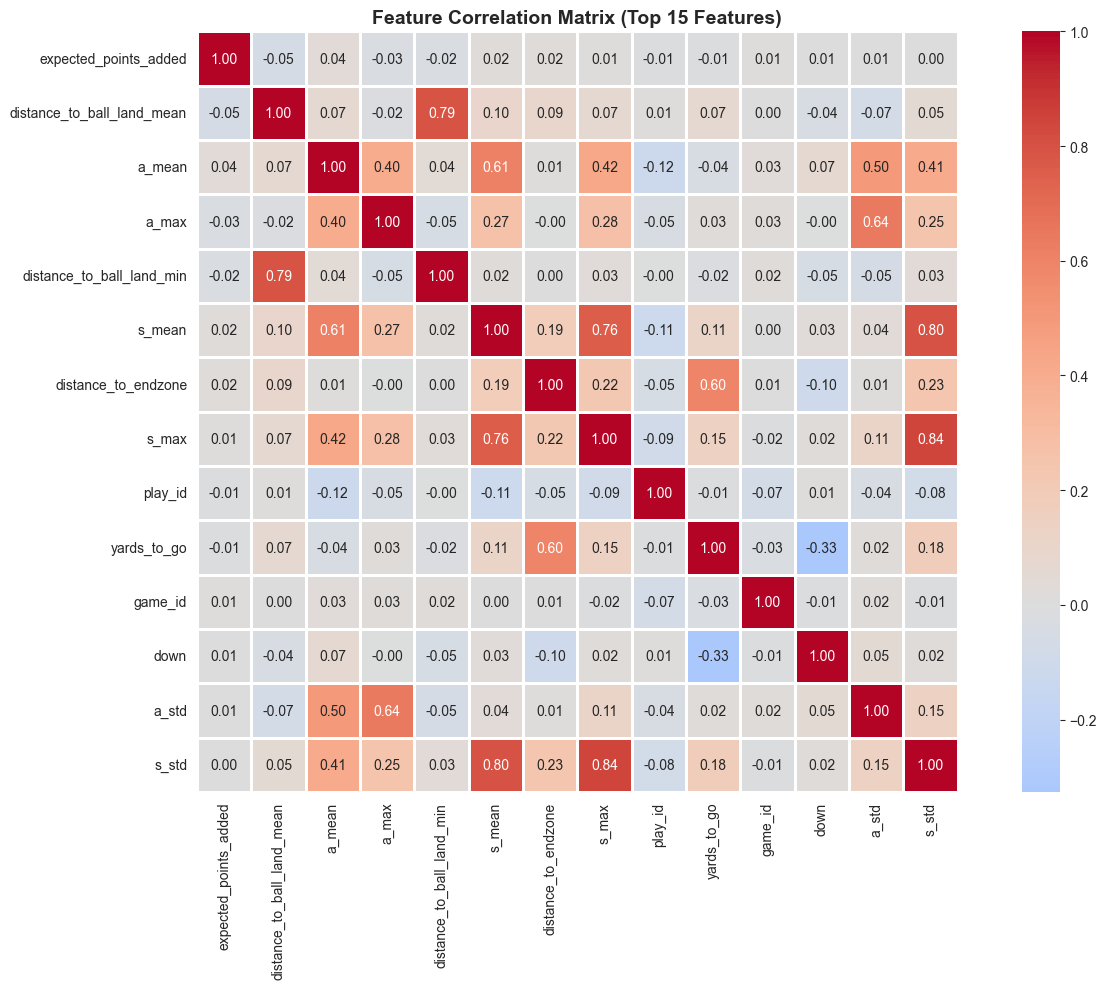


Strongest Predictors of Expected Points Added:
expected_points_added         1.000000
distance_to_ball_land_mean    0.054596
a_mean                        0.040257
a_max                         0.030050
distance_to_ball_land_min     0.020683
s_mean                        0.018513
distance_to_endzone           0.017152
s_max                         0.014518
play_id                       0.013764
yards_to_go                   0.012782
Name: expected_points_added, dtype: float64


In [18]:
# Cell 14: Correlation Analysis
print("=== Feature Correlation Analysis ===\n")

# Select numeric features for correlation
numeric_features = play_features.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = play_features[numeric_features].corr()

# Focus on correlations with available success metrics
# Check which success metrics are actually in the dataframe
available_metrics = []
if 'expected_points_added' in correlation_matrix.columns:
    available_metrics.append('expected_points_added')
if 'yards_gained' in correlation_matrix.columns:
    available_metrics.append('yards_gained')
if 'pre_penalty_yards_gained' in correlation_matrix.columns:
    available_metrics.append('pre_penalty_yards_gained')

if available_metrics:
    success_corr = correlation_matrix[available_metrics].sort_values(
        by=available_metrics[0], ascending=False
    )
    
    print(f"Correlations with Red Zone Success Metrics ({', '.join(available_metrics)}):")
    print(success_corr.head(15))
    print()

# Visualize correlation matrix for top features
plt.figure(figsize=(14, 10))
top_features = correlation_matrix[available_metrics[0]].abs().sort_values(ascending=False).head(15).index
sns.heatmap(
    correlation_matrix.loc[top_features, top_features],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1
)
plt.title('Feature Correlation Matrix (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strongest predictors
print("\nStrongest Predictors of Expected Points Added:")
if 'expected_points_added' in correlation_matrix.columns:
    epa_corr = correlation_matrix['expected_points_added'].abs().sort_values(ascending=False)
    print(epa_corr.head(10))

In [21]:
# Cell 15: Key Insights Summary
print("=" * 60)
print("RED ZONE ANALYSIS - KEY INSIGHTS SUMMARY")
print("=" * 60)

# 1. Overall Red Zone Statistics
print("\n1. OVERALL RED ZONE STATISTICS")
print(f"   Total Red Zone Plays: {len(redzone_plays):,}")
print(f"   Total Red Zone Passes: {redzone_plays['pass_result'].notna().sum():,}")

# Pass result breakdown
if 'pass_result' in redzone_plays.columns:
    pass_results = redzone_plays['pass_result'].value_counts()
    print(f"\n   Pass Result Breakdown:")
    for result, count in pass_results.items():
        pct = (count / len(redzone_plays)) * 100
        print(f"     - {result}: {count} ({pct:.1f}%)")

# 2. Red Zone Success Metrics
print("\n2. RED ZONE SUCCESS METRICS")
if 'expected_points_added' in redzone_plays.columns:
    avg_epa = redzone_plays['expected_points_added'].mean()
    print(f"   Average EPA: {avg_epa:.3f}")
    
if 'yards_gained' in redzone_plays.columns:
    avg_yards = redzone_plays['yards_gained'].mean()
    print(f"   Average Yards Gained: {avg_yards:.2f}")
    
    # Success by down
    print(f"\n   Performance by Down:")
    for down in sorted(redzone_plays['down'].dropna().unique()):
        down_plays = redzone_plays[redzone_plays['down'] == down]
        avg_yards_down = down_plays['yards_gained'].mean()
        print(f"     - Down {int(down)}: {avg_yards_down:.2f} yards/play")

# 3. Formation and Coverage Insights
print("\n3. FORMATION & COVERAGE INSIGHTS")
if 'offense_formation' in redzone_plays.columns:
    top_formations = redzone_plays['offense_formation'].value_counts().head(3)
    print(f"   Top Offensive Formations:")
    for formation, count in top_formations.items():
        pct = (count / len(redzone_plays)) * 100
        print(f"     - {formation}: {count} plays ({pct:.1f}%)")

if 'team_coverage_type' in redzone_plays.columns:
    top_coverages = redzone_plays['team_coverage_type'].value_counts().head(3)
    print(f"\n   Top Defensive Coverages:")
    for coverage, count in top_coverages.items():
        pct = (count / len(redzone_plays)) * 100
        print(f"     - {coverage}: {count} plays ({pct:.1f}%)")

# 4. Player Movement Insights
print("\n4. PLAYER MOVEMENT INSIGHTS")
if 'player_role' in redzone_tracking.columns:
    print(f"   Average Speed by Role:")
    role_speed = redzone_tracking.groupby('player_role')['s'].mean().sort_values(ascending=False)
    for role, speed in role_speed.head(5).items():
        print(f"     - {role}: {speed:.2f} yards/sec")

# 5. Feature Correlation Insights
print("\n5. KEY PREDICTIVE FEATURES")
if len(available_metrics) > 0 and 'success_corr' in locals():
    print(f"   Features most correlated with {available_metrics[0]}:")
    # Get top correlated features (excluding the metric itself)
    top_corr = success_corr[available_metrics[0]].abs().sort_values(ascending=False)
    top_corr = top_corr[top_corr.index != available_metrics[0]].head(5)
    
    for feat, corr_val in top_corr.items():
        print(f"     - {feat}: {corr_val:.3f}")

# 6. Distance to Endzone Analysis
print("\n6. DISTANCE TO ENDZONE ANALYSIS")
if 'distance_to_endzone' in redzone_plays.columns:
    distance_bins = pd.cut(redzone_plays['distance_to_endzone'], bins=[0, 5, 10, 15, 20], include_lowest=True)
    print(f"   Plays by Distance to Endzone:")
    for bin_range, count in distance_bins.value_counts().sort_index().items():
        pct = (count / len(redzone_plays)) * 100
        print(f"     - {bin_range}: {count} plays ({pct:.1f}%)")

print("\n" + "=" * 60)
print("Analysis Complete!")
print("=" * 60)

RED ZONE ANALYSIS - KEY INSIGHTS SUMMARY

1. OVERALL RED ZONE STATISTICS
   Total Red Zone Plays: 2,146
   Total Red Zone Passes: 2,146

   Pass Result Breakdown:
     - C: 1338 (62.3%)
     - I: 757 (35.3%)
     - IN: 51 (2.4%)

2. RED ZONE SUCCESS METRICS
   Average EPA: 0.257
   Average Yards Gained: 4.53

   Performance by Down:
     - Down 1: 4.83 yards/play
     - Down 2: 4.36 yards/play
     - Down 3: 4.69 yards/play
     - Down 4: 3.01 yards/play

3. FORMATION & COVERAGE INSIGHTS
   Top Offensive Formations:
     - SHOTGUN: 1495 plays (69.7%)
     - EMPTY: 289 plays (13.5%)
     - SINGLEBACK: 225 plays (10.5%)

   Top Defensive Coverages:
     - COVER_1_MAN: 622 plays (29.0%)
     - COVER_4_ZONE: 505 plays (23.5%)
     - COVER_0_MAN: 454 plays (21.2%)

4. PLAYER MOVEMENT INSIGHTS
   Average Speed by Role:
     - Targeted Receiver: 3.83 yards/sec
     - Other Route Runner: 3.77 yards/sec
     - Defensive Coverage: 2.22 yards/sec
     - Passer: 1.88 yards/sec

5. KEY PREDICTIVE F